### Tool
---
- For our chatbot agent we will use 2 tools:
  1. websearch tool
  2. weather search tool

In [1]:
import requests
import os 
from dotenv import load_dotenv
load_dotenv()
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

In [2]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API")

In [25]:
# web-search tool
search_tool = TavilySearch(max_results = 3, search_depth = "advanced")

In [4]:
# weather tool
@tool(name_or_callable = "weather_tool" , description = "Get current weather update for a given city.")
def get_weather(city: str)-> str:
    """Get a detailed current weather update for a given city including temp, humidity, and wind.

    Args:
        city (str): Name of the city (e.g., "Dhaka", "New York")

    Returns:
        str: Comprehensive weather summary string.
    """
    api_key = os.getenv("OPEN_WEATHER_API")
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    
    try:
        response = requests.get(url, timeout=10).json()
        if str(response.get("cod")) != "200":
            error_msg = response.get("message", "Unknown error").capitalize()
            return f"Could not find weather data for '{city}'. Reason: {error_msg}."
        
        weather_desc = response["weather"][0]["description"].capitalize()
        temp = response["main"]["temp"]
        feels_like = response["main"]["feels_like"]
        humidity = response["main"]["humidity"]
        pressure = response["main"]["pressure"]
        wind_speed = response["wind"]["speed"]  
        visibility_km = response.get("visibility", 0) / 1000 # Convert meters to km
        country = response["sys"]["country"]
        city_name = response["name"]
        
        detailed_report = (
            f"Current Weather Report for {city_name}, {country}:\n"
            f"- Condition: {weather_desc}\n"
            f"- Temperature: {temp}°C (Feels like: {feels_like}°C)\n"
            f"- Humidity: {humidity}%\n"
            f"- Wind Speed: {wind_speed} m/s\n"
            f"- Barometric Pressure: {pressure} hPa\n"
            f"- Visibility: {visibility_km:.1f} km"
        )
        return detailed_report
    except Exception as e:
        return f"An error occurred while fetching the weather update: {str(e)}"

In [5]:
print(get_weather.invoke({"city" : "dhaka"}))

Current Weather Report for Dhaka, BD:
- Condition: Haze
- Temperature: 27.99°C (Feels like: 33.54°C)
- Humidity: 89%
- Wind Speed: 2.57 m/s
- Barometric Pressure: 1005 hPa
- Visibility: 3.5 km


In [26]:
tools = [get_weather , search_tool]

### Memory Layer

In [7]:
from pymongo import MongoClient, DESCENDING
from datetime import datetime, timezone

In [8]:
client = MongoClient(os.getenv("MONGO_URI"))
db =  client[os.getenv("MONGO_DB")]

In [9]:
db

Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'chatbot_db')

In [10]:
# we need to things 1. user_facts and 2. conversations
facts_col = db["user_facts"]
conv_col = db["conversations"]

# indexes
facts_col.create_index([("user_id" , 1) , ("created_at" , DESCENDING)])
conv_col.create_index([("thread_id", 1), ("created_at", 1)])

'thread_id_1_created_at_1'

In [11]:
# function to save facts for a user
def save_fact(user_id: str , fact: str):
    facts_col.insert_one({
        "user_id": user_id,
        "fact": fact,
        "created_at": datetime.now(timezone.utc)
    })

In [12]:
# function to get facts about a user
def get_facts(user_id: str) -> list[str]:
    docs = facts_col.find(
        {"user_id" : user_id},
        sort = [("created_at" , DESCENDING)],
        limit = 20
    )
    return [d["fact"] for d in docs]

In [13]:
def save_message(thread_id: str, role: str, content: str):
    conv_col.insert_one({
        "thread_id": thread_id,
        "role": role,
        "content": content,
        "created_at": datetime.now(timezone.utc)
    })

In [14]:
def get_conversation(thread_id: str) -> list[dict]:
    """load full history for a thread."""
    return list(conv_col.find(
        {"thread_id": thread_id},
        sort=[("created_at", 1)],
        projection={"_id": 0, "role": 1, "content": 1}
    ))

### Agent part
---
Now we have to build the agent workflow

In [15]:
from langgraph.checkpoint.mongodb import MongoDBSaver
from pymongo import MongoClient

from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode
from langchain_groq.chat_models import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [16]:
# Define agent state
from typing import Annotated, Optional
from typing_extensions import TypedDict

class AgentState(TypedDict):
    messages: Annotated[list , add_messages]
    user_id: Optional[str] 

In [17]:
llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0.5
)

In [34]:
from langchain_community.tools.tavily_search import TavilySearchResults
from pydantic import BaseModel, Field
from typing import Literal

In [35]:
class StrictTavilySchema(BaseModel):
    query: str = Field(description="The search query string")
    topic: Literal["general", "news", "finance"] = Field(
        default="general", 
        description="The category of search. Use 'news' for sports/current events."
    )

In [36]:
search_tool = TavilySearch(max_results=3)
search_tool.args_schema = StrictTavilySchema

In [37]:
tools = [search_tool , get_weather]

In [38]:
# bind tools to the llm
llm_with_tools = llm.bind_tools(tools)

In [39]:
# agent node
def agent_node(state: AgentState):
    # get the facts
    user_id = state.get("user_id" , "default_user")
    facts = get_facts(user_id)
    memory_context = "\n".join(f"- {f}" for f in facts) if facts else "None yet."
    system = SystemMessage(content = f"""You are a helpful assistant with memory.
    
What you know about this user:
{memory_context}

Use tools when you need current information (weather, web search).
If the user shares something important about themselves, note it.""")
    
    response = llm_with_tools.invoke(
        [system] + state["messages"]
    )
    return {"messages": [response]}

In [40]:
# routing for tool usage
def should_use_tools(state: AgentState):
    # get the last message
    last_message = state['messages'][-1]
    # check if last message is a tool calls or not
    if getattr(last_message, "tool_calls", None):
        return "tools"
    
    return "__end__"

In [41]:
tools

[TavilySearch(args_schema=<class '__main__.StrictTavilySchema'>, max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 StructuredTool(name='weather_tool', description='Get current weather update for a given city.', args_schema=<class 'langchain_core.utils.pydantic.weather_tool'>, func=<function get_weather at 0x000002314E316520>)]

In [42]:
# build the graph
def build_graph():
    tool_node = ToolNode(tools = tools)
    
    graph = StateGraph(AgentState)
    # add nodes
    graph.add_node("agent" , agent_node)
    graph.add_node("tools" , tool_node)
    
    graph.add_edge(START , "agent")
    graph.add_conditional_edges(
        "agent",should_use_tools,
        {
            "tools": "tools",
            "__end__": END
        }
    )
    graph.add_edge("tools" , "agent")
    
    # mongodb checkpointer for persistent thread state
    mongo_client = MongoClient(os.getenv("MONGO_URI"))
    checkpointer = MongoDBSaver(
        client = mongo_client, db_name = os.getenv("MONGO_DB" , "chatbot_db")
    )
    workflow = graph.compile(checkpointer)
    return workflow

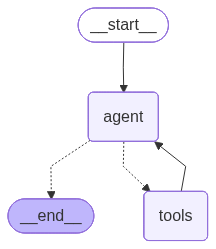

In [43]:
workflow = build_graph()
workflow

In [53]:
# Lets test the workflow
import uuid

config = {"configurable": {"thread_id": f"test-thread-{uuid.uuid4().hex[:6]}"}}

response = workflow.invoke({
    "messages": [HumanMessage(content = "todays weather brief in dhaka")], 
    "user_id": "test_user"
}, config = config)

In [54]:
for message in response['messages']:
    print(message)
    print("\n\n")

content='todays weather brief in dhaka' additional_kwargs={} response_metadata={} id='c9b3dc76-fd88-4c2d-8cc3-2c9a784f46c7'



content='' additional_kwargs={'tool_calls': [{'id': 'ex29344ha', 'function': {'arguments': '{"city":"Dhaka"}', 'name': 'weather_tool'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 486, 'total_tokens': 503, 'completion_time': 0.056582115, 'completion_tokens_details': None, 'prompt_time': 0.024865746, 'prompt_tokens_details': None, 'queue_time': 0.327155922, 'total_time': 0.081447861}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e5093-40a4-7ea3-a177-414a73866bb2-0' tool_calls=[{'name': 'weather_tool', 'args': {'city': 'Dhaka'}, 'id': 'ex29344ha', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 486, 'output_tokens': 17, 'total_tok